In [1]:
import xarray as xr
from xcube_resampling import resample_in_space

In [2]:
path = (
    "https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:202510-s03slsrbt-global/09/products/cpm_v256/"
    "S3A_SL_1_RBT____20251009T011313_20251009T011613_20251009T030735_0179_131_202_3420_PS1_O_NR_004.zarr"
)

In [3]:
%%time
dt = xr.open_datatree(path, engine="eopf-zarr", op_mode="native", chunks={})
dt

CPU times: user 1.28 s, sys: 106 ms, total: 1.38 s
Wall time: 3.3 s


<xarray.DataTree>
Group: /
│   Attributes: (2)
├── Group: /conditions
│   ├── Group: /conditions/geometry_tn
│   │       Dimensions:           (rows: 1200, columns: 130)
│   │       Coordinates:
│   │           x                 (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   │           y                 (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   │       Dimensions without coordinates: rows, columns
│   │       Data variables:
│   │           sat_azimuth_tn    (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   │           sat_path_tn       (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   │           sat_zenith_tn     (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   │           solar_azimuth_tn  (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   │           solar_path_tn     (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   │           solar_zenith_tn   (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   ├── Group: /conditions/geometry_to
│   │       Dimensions:           (rows: 1200, columns: 130)
│   │       Dimensions without coordinates: rows, columns
│   │       Data variables:
│   │           sat_azimuth_to    (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   │           sat_path_to       (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   │           sat_zenith_to     (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   │           solar_azimuth_to  (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   │           solar_path_to     (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   │           solar_zenith_to   (rows, columns) float64 1MB dask.array<chunksize=(1200, 130), meta=np.ndarray>
│   ├── Group: /conditions/instrument
│   │   ├── Group: /conditions/instrument/anadir
│   │   │   ├── Group: /conditions/instrument/anadir/s1
│   │   │   │       Dimensions:                        (detectors: 4, integrators: 2, rows: 2400,
│   │   │   │                                           uncertainties: 300)
│   │   │   │       Dimensions without coordinates: detectors, integrators, rows, uncertainties
│   │   │   │       Data variables: (12/14)
│   │   │   │           s1_band_centre_an              (detectors) float64 32B dask.array<chunksize=(4,), meta=np.ndarray>
│   │   │   │           s1_bandwidth_an                (detectors) float64 32B dask.array<chunksize=(4,), meta=np.ndarray>
│   │   │   │           s1_cal_gain_an                 (detectors, integrators) float64 64B dask.array<chunksize=(4, 2), meta=np.ndarray>
│   │   │   │           s1_cal_offset_an               (detectors, integrators, rows) float64 154kB dask.array<chunksize=(4, 2, 2400), meta=np.ndarray>
│   │   │   │           s1_dl_bb_an                    (detectors, integrators, rows) float64 154kB dask.array<chunksize=(4, 2, 2400), meta=np.ndarray>
│   │   │   │           s1_dl_viscal_an                (detectors, integrators) float64 64B dask.array<chunksize=(4, 2), meta=np.ndarray>
│   │   │   │           ...                             ...
│   │   │   │           s1_l_bb_an                     (detectors, rows) float64 77kB dask.array<chunksize=(4, 2400), meta=np.ndarray>
│   │   │   │           s1_l_viscal_an                 (detectors) float64 32B dask.array<chunksize=(4,), meta=np.ndarray>
│   │   │   │           s1_radiometric_uncertainty_an  (detectors, uncertainties) float64 10kB dask.array<chunksize=(4, 300), meta=np.ndarray>
│   │   │   │           s1_scene_radiance_an           (uncertainties) float64 2kB dask.array<chunksize=(300,), meta=np.ndarray>
│   │   │   │           s1_solar_irradiance_an         (detectors) float64 32B

In [4]:
%%time
ds_anadir = dt.measurements.anadir.to_dataset()
ds_anadir_rect = resample_in_space(ds_anadir)
ds_anadir_rect

CPU times: user 8.85 s, sys: 2.87 s, total: 11.7 s
Wall time: 49.5 s


<xarray.Dataset> Size: 443MB
Dimensions:         (rows: 2400, columns: 3000, lon: 2748, lat: 2127)
Coordinates:
    x               (rows, columns) float64 58MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    y               (rows, columns) float64 58MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    spatial_ref     int64 8B 0
  * lon             (lon) float64 22kB 115.0 115.0 115.0 ... 132.9 132.9 132.9
  * lat             (lat) float64 17kB -20.99 -21.0 -21.01 ... -34.81 -34.81
Dimensions without coordinates: rows, columns
Data variables:
    elevation       (lat, lon) float64 47MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    s1_radiance_an  (lat, lon) float64 47MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    s2_radiance_an  (lat, lon) float64 47MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    s3_radiance_an  (lat, lon) float64 47MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    s4_radiance_an  (lat, lon) float64 47MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    s5_radiance_an  (lat, lon) float64 47MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    s6_radiance_an  (lat, lon) float64 47MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>

CPU times: user 7.63 s, sys: 4.63 s, total: 12.3 s
Wall time: 33.8 s


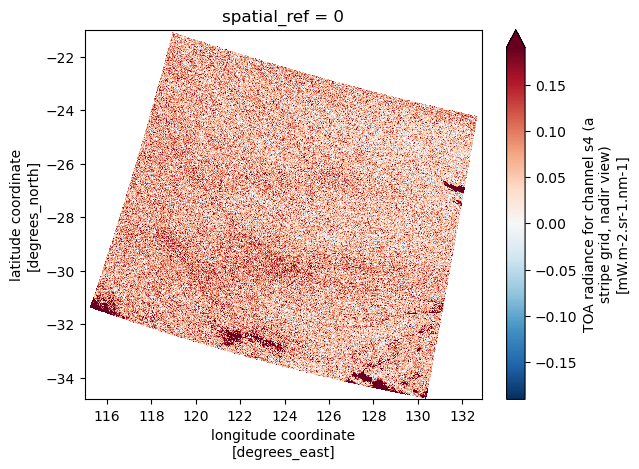

In [5]:
%%time
ds_anadir_rect.s4_radiance_an.plot(robust=True)

In [6]:
%%time
ds_bnadir = dt.measurements.bnadir.to_dataset()
ds_bnadir_rect = resample_in_space(ds_bnadir)
ds_bnadir_rect

CPU times: user 9.38 s, sys: 2.27 s, total: 11.6 s
Wall time: 50.5 s


<xarray.Dataset> Size: 302MB
Dimensions:         (rows: 2400, columns: 3000, lon: 2748, lat: 2127)
Coordinates:
    x               (rows, columns) float64 58MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    y               (rows, columns) float64 58MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    spatial_ref     int64 8B 0
  * lon             (lon) float64 22kB 115.0 115.0 115.0 ... 132.9 132.9 132.9
  * lat             (lat) float64 17kB -20.99 -21.0 -21.01 ... -34.81 -34.81
Dimensions without coordinates: rows, columns
Data variables:
    elevation       (lat, lon) float64 47MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    s4_radiance_bn  (lat, lon) float64 47MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    s5_radiance_bn  (lat, lon) float64 47MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    s6_radiance_bn  (lat, lon) float64 47MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>

CPU times: user 6.88 s, sys: 3.7 s, total: 10.6 s
Wall time: 33.3 s


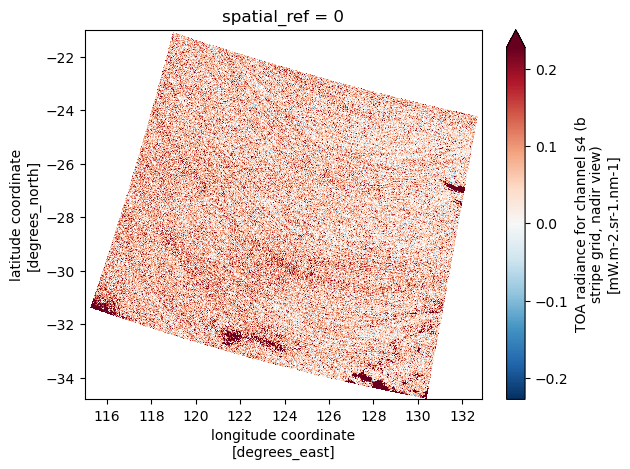

In [7]:
%%time
ds_bnadir_rect.s4_radiance_bn.plot(robust=True)

In [8]:
%%time
ds_fnadir = dt.measurements.fnadir.to_dataset()
ds_fnadir_rect = resample_in_space(ds_fnadir)
ds_fnadir_rect

CPU times: user 2.74 s, sys: 592 ms, total: 3.33 s
Wall time: 18.5 s


<xarray.Dataset> Size: 78MB
Dimensions:      (rows: 1200, columns: 1500, lon: 1984, lat: 1536)
Coordinates:
    x            (rows, columns) float64 14MB dask.array<chunksize=(600, 750), meta=np.ndarray>
    y            (rows, columns) float64 14MB dask.array<chunksize=(600, 750), meta=np.ndarray>
    spatial_ref  int64 8B 0
  * lon          (lon) float64 16kB 115.0 115.0 115.0 ... 132.8 132.9 132.9
  * lat          (lat) float64 12kB -20.99 -21.0 -21.01 ... -34.79 -34.8 -34.81
Dimensions without coordinates: rows, columns
Data variables:
    elevation    (lat, lon) float64 24MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    f1_bt_fn     (lat, lon) float64 24MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>

CPU times: user 2.13 s, sys: 885 ms, total: 3.01 s
Wall time: 9.77 s


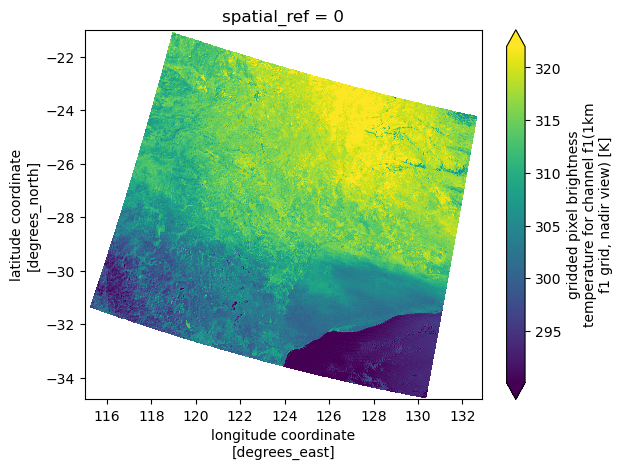

In [9]:
%%time
ds_fnadir_rect.f1_bt_fn.plot(robust=True)

In [10]:
%%time
ds_inadir = dt.measurements.inadir.to_dataset()
ds_inadir_rect = resample_in_space(ds_inadir)
ds_inadir_rect

CPU times: user 2.63 s, sys: 689 ms, total: 3.32 s
Wall time: 19 s


<xarray.Dataset> Size: 151MB
Dimensions:      (rows: 1200, columns: 1500, lon: 1984, lat: 1536)
Coordinates:
    x            (rows, columns) float64 14MB dask.array<chunksize=(600, 750), meta=np.ndarray>
    y            (rows, columns) float64 14MB dask.array<chunksize=(600, 750), meta=np.ndarray>
    spatial_ref  int64 8B 0
  * lon          (lon) float64 16kB 115.0 115.0 115.0 ... 132.8 132.9 132.9
  * lat          (lat) float64 12kB -20.99 -21.0 -21.01 ... -34.79 -34.8 -34.81
Dimensions without coordinates: rows, columns
Data variables:
    elevation    (lat, lon) float64 24MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    f2_bt_in     (lat, lon) float64 24MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    s7_bt_in     (lat, lon) float64 24MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    s8_bt_in     (lat, lon) float64 24MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    s9_bt_in     (lat, lon) float64 24MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>

CPU times: user 2.57 s, sys: 922 ms, total: 3.49 s
Wall time: 9.89 s


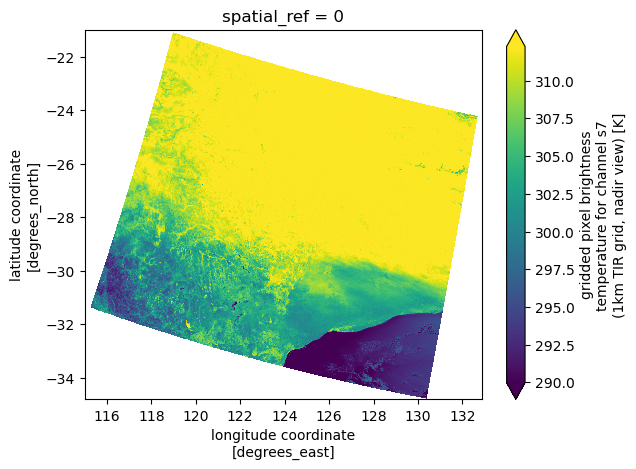

In [11]:
%%time
ds_inadir_rect.s7_bt_in.plot(robust=True)

CPU times: user 11 s, sys: 2.45 s, total: 13.4 s
Wall time: 47.2 s


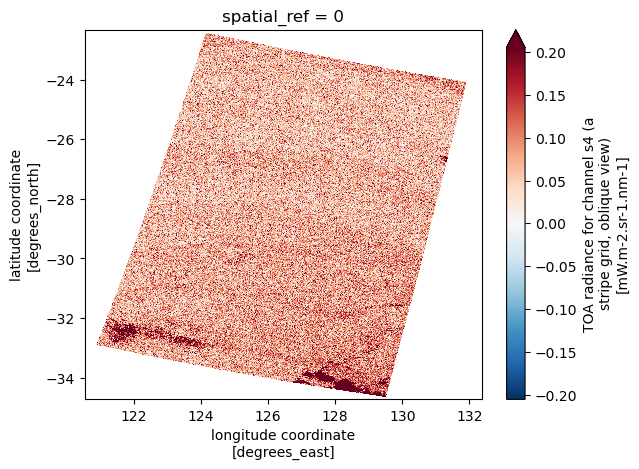

In [12]:
%%time
ds = dt.measurements.aoblique.to_dataset()
ds_rect = resample_in_space(ds)
ds_rect.s4_radiance_ao.plot(robust=True)

In [13]:
%%time
ds_boblique = dt.measurements.boblique.to_dataset()
ds_boblique_rect = resample_in_space(ds_boblique)
ds_boblique_rect

CPU times: user 5.72 s, sys: 1.08 s, total: 6.8 s
Wall time: 28.3 s


<xarray.Dataset> Size: 200MB
Dimensions:         (rows: 2400, columns: 1800, lon: 1971, lat: 2067)
Coordinates:
    x               (rows, columns) float64 35MB dask.array<chunksize=(800, 600), meta=np.ndarray>
    y               (rows, columns) float64 35MB dask.array<chunksize=(800, 600), meta=np.ndarray>
    spatial_ref     int64 8B 0
  * lon             (lon) float64 16kB 120.5 120.6 120.6 ... 132.4 132.4 132.4
  * lat             (lat) float64 17kB -22.33 -22.34 -22.34 ... -34.72 -34.73
Dimensions without coordinates: rows, columns
Data variables:
    elevation       (lat, lon) float64 33MB dask.array<chunksize=(1200, 900), meta=np.ndarray>
    s4_radiance_bo  (lat, lon) float64 33MB dask.array<chunksize=(1200, 900), meta=np.ndarray>
    s5_radiance_bo  (lat, lon) float64 33MB dask.array<chunksize=(1200, 900), meta=np.ndarray>
    s6_radiance_bo  (lat, lon) float64 33MB dask.array<chunksize=(1200, 900), meta=np.ndarray>

CPU times: user 4.94 s, sys: 999 ms, total: 5.94 s
Wall time: 18.6 s


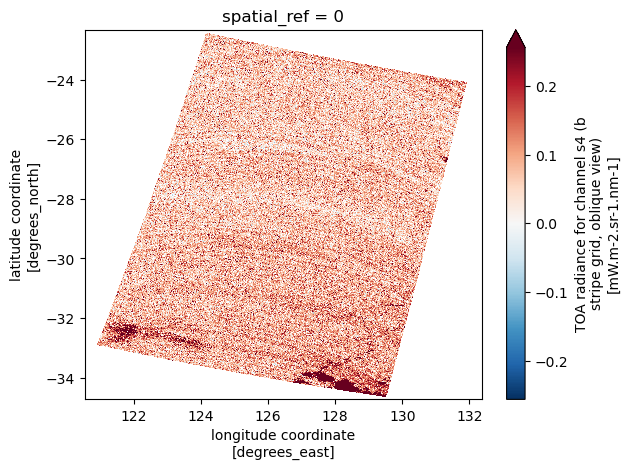

In [14]:
%%time
ds_boblique_rect.s4_radiance_bo.plot(robust=True)

In [15]:
%%time
ds_foblique = dt.measurements.foblique.to_dataset()
ds_foblique_rect = resample_in_space(ds_foblique)
ds_foblique_rect

CPU times: user 1.99 s, sys: 349 ms, total: 2.34 s
Wall time: 12 s


<xarray.Dataset> Size: 59MB
Dimensions:      (rows: 1200, columns: 900, lon: 1577, lat: 1654)
Coordinates:
    x            (rows, columns) float64 9MB dask.array<chunksize=(600, 450), meta=np.ndarray>
    y            (rows, columns) float64 9MB dask.array<chunksize=(600, 450), meta=np.ndarray>
    spatial_ref  int64 8B 0
  * lon          (lon) float64 13kB 120.5 120.6 120.6 ... 132.4 132.4 132.4
  * lat          (lat) float64 13kB -22.32 -22.33 -22.34 ... -34.71 -34.72
Dimensions without coordinates: rows, columns
Data variables:
    elevation    (lat, lon) float64 21MB dask.array<chunksize=(1200, 900), meta=np.ndarray>
    f1_bt_fo     (lat, lon) float64 21MB dask.array<chunksize=(1200, 900), meta=np.ndarray>

CPU times: user 1.64 s, sys: 211 ms, total: 1.85 s
Wall time: 5.59 s


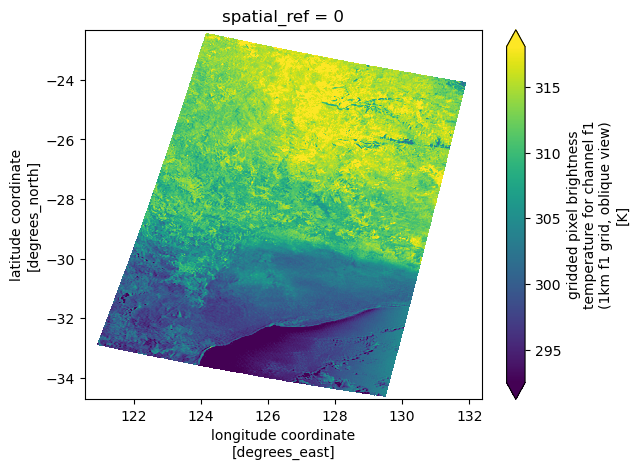

In [16]:
%%time
ds_foblique_rect.f1_bt_fo.plot(robust=True)

In [17]:
%%time
ds_ioblique = dt.measurements.ioblique.to_dataset()
ds_ioblique_rect = resample_in_space(ds_ioblique)

CPU times: user 1.86 s, sys: 397 ms, total: 2.26 s
Wall time: 11.9 s


CPU times: user 1.89 s, sys: 280 ms, total: 2.17 s
Wall time: 5.54 s


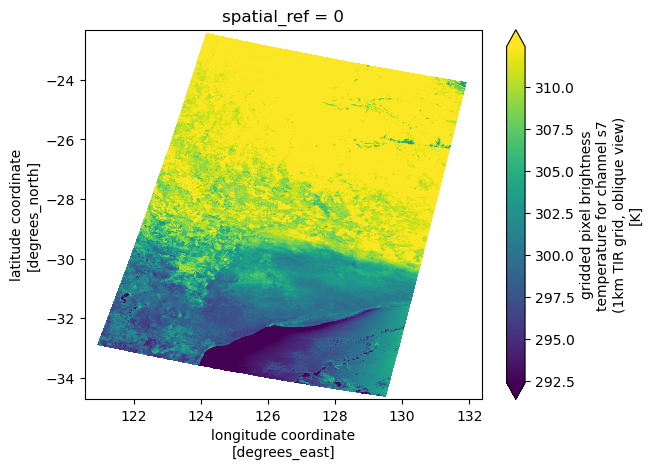

In [18]:
%%time
ds_ioblique_rect.s7_bt_io.plot(robust=True)